# Time Complexity Analysis

Este notebook mede o tempo de geracao do SynCo variando apenas o numero de vertices. Os tamanhos comecam em `1_000` e dobram ate `MAX_N`. O numero de execucoes por tamanho e controlado por `NUM_EXECUTIONS`.

In [7]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import networkit as nk
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd()
if ROOT.name in {"experiments", "examples"}:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from synco import SynCoGenerator

OUTPUT_DIR = ROOT / "experiments" / "complexity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR

PosixPath('/home/gui-messias/Documents/Doutorado/SynCo/SCAtt_graph_generator/experiments/complexity')

## Parameters

Todos os hiperparametros estruturais ficam fixos. Apenas `n`, `y`, `e` e `rho` escalam. Usamos `rho = EDGES_PER_NODE * n`, mantendo o numero de arestas proporcional ao numero de vertices. A conexao automatica de nos isolados fica desligada por padrao para medir a escalabilidade do nucleo gerador.

In [8]:
SEED = 2026
NUM_EXECUTIONS = 1

START_N = 1_000
MAX_N = 2_048_000 
EDGES_PER_NODE = 5

FEATURE_DIM = 60
HOMOGENEOUS_EDGE_FRACTION = 0.70
BUILD_SUBGRAPHS = False
CONNECT_ISOLATED_NODES = False
COMPUTE_COMPONENT_METRICS = True
COMPUTE_EDGE_MIXING_METRICS = True
SAVE_INTERMEDIATE_CSV = True

def doubling_values(start, max_value):
    values = []
    current = int(start)
    while current <= max_value:
        values.append(current)
        current *= 2
    return values

N_VALUES = doubling_values(START_N, MAX_N)
N_VALUES

[1000,
 2000,
 4000,
 8000,
 16000,
 32000,
 64000,
 128000,
 256000,
 512000,
 1024000,
 2048000]

In [9]:
def allocate_integer_total(total, weights):
    weights = np.asarray(weights, dtype=float)
    raw = total * weights / weights.sum()
    base = np.floor(raw).astype(int)
    missing = int(total - base.sum())
    order = np.argsort(-(raw - base))
    for i in order[:missing]:
        base[i] += 1
    return base.tolist()

def allocate_capped_total(total, weights, caps):
    values = allocate_integer_total(total, weights)
    values = [min(value, cap) for value, cap in zip(values, caps)]
    missing = int(total - sum(values))
    while missing > 0:
        available = [idx for idx, (value, cap) in enumerate(zip(values, caps)) if value < cap]
        if not available:
            break
        idx = max(available, key=lambda i: weights[i])
        values[idx] += 1
        missing -= 1
    return values

def params_for_n(n):
    y = allocate_integer_total(n, [1, 1, 1])
    rho = EDGES_PER_NODE * n
    max_total_edges = n * (n - 1) // 2
    rho = min(rho, max_total_edges)

    class_caps = [class_size * (class_size - 1) // 2 for class_size in y]
    homogeneous_total = min(int(rho * HOMOGENEOUS_EDGE_FRACTION), sum(class_caps))
    e = allocate_capped_total(homogeneous_total, [150, 200, 100], class_caps)

    return {
        "n": n,
        "y": y,
        "k": len(y),
        "e": e,
        "A_in": [
            torch.tensor([[1.0]]),
            torch.tensor([[0.6, 0.3, 0.1], [0.1, 0.7, 0.2], [0.0, 0.3, 0.7]]),
            torch.tensor([[0.9, 0.1], [0.1, 0.9]]),
        ],
        "dst": ["power_law", "normal", "uniform"],
        "rho": rho,
        "A_out": torch.tensor([[0.0, 0.2, 0.8], [0.3, 0.0, 0.7], [0.5, 0.5, 0.0]]),
        "S": [torch.tensor([1.0]), torch.tensor([0.4, 0.3, 0.3]), torch.tensor([0.9, 0.1])],
        "d": FEATURE_DIM,
        "alpha_feat": 0.3,
        "alpha_topo": 0.5,
        "build_subgraphs": BUILD_SUBGRAPHS,
        "connect_isolated_nodes": CONNECT_ISOLATED_NODES,
    }

def compute_graph_metrics(graph):
    nk_graph = graph.graph
    n = graph.num_nodes()
    m = graph.num_edges()

    degrees = np.fromiter((nk_graph.degree(u) for u in nk_graph.iterNodes()), dtype=np.int64, count=n)
    isolated_nodes = int(np.count_nonzero(degrees == 0))

    metrics = {
        "isolated_nodes": isolated_nodes,
        "isolated_fraction": isolated_nodes / max(n, 1),
        "mean_degree": float(degrees.mean()) if n else 0.0,
        "min_degree": int(degrees.min()) if n else 0,
        "max_degree": int(degrees.max()) if n else 0,
        "density": (2 * m) / (n * (n - 1)) if n > 1 else 0.0,
    }

    if graph.y is not None:
        labels = graph.y.detach().cpu().numpy()
        class_counts = np.bincount(labels.astype(np.int64), minlength=int(labels.max()) + 1 if len(labels) else 0)
        for class_id, count in enumerate(class_counts):
            metrics[f"class_{class_id}_nodes"] = int(count)

        if COMPUTE_EDGE_MIXING_METRICS:
            heterogeneous_edges = 0
            for u, v in nk_graph.iterEdges():
                heterogeneous_edges += int(labels[u] != labels[v])
            metrics["heterogeneous_edges_actual"] = int(heterogeneous_edges)
            metrics["homogeneous_edges_actual"] = int(m - heterogeneous_edges)
            metrics["heterogeneous_edge_fraction"] = heterogeneous_edges / max(m, 1)

    if COMPUTE_COMPONENT_METRICS:
        components = nk.components.ConnectedComponents(nk_graph).run()
        component_sizes_raw = components.getComponentSizes()
        if hasattr(component_sizes_raw, "values"):
            component_sizes = list(component_sizes_raw.values())
        else:
            component_sizes = list(component_sizes_raw)
        largest_component_size = max(component_sizes) if component_sizes else 0
        metrics["connected_components"] = int(components.numberOfComponents())
        metrics["largest_component_size"] = int(largest_component_size)
        metrics["largest_component_fraction"] = largest_component_size / max(n, 1)

    return metrics

pd.DataFrame([
    {
        "n": n,
        "rho": params_for_n(n)["rho"],
        "y": params_for_n(n)["y"],
        "e": params_for_n(n)["e"],
        "heterogeneous_edges": params_for_n(n)["rho"] - sum(params_for_n(n)["e"]),
    }
    for n in N_VALUES
])

,n,rho,y,e,heterogeneous_edges
0,1000,5000,"[334, 333, 333]","[1167, 1555, 778]",1500
1,2000,10000,"[667, 667, 666]","[2333, 3111, 1556]",3000
2,4000,20000,"[1334, 1333, 1333]","[4667, 6222, 3111]",6000
3,8000,40000,"[2667, 2667, 2666]","[9333, 12445, 6222]",12000
4,16000,80000,"[5334, 5333, 5333]","[18667, 24889, 12444]",24000
5,32000,160000,"[10667, 10667, 10666]","[37333, 49778, 24889]",48000
6,64000,320000,"[21334, 21333, 21333]","[74667, 99555, 49778]",96000
7,128000,640000,"[42667, 42667, 42666]","[149333, 199111, 99556]",192000
8,256000,1280000,"[85334, 85333, 85333]","[298667, 398222, 199111]",384000
9,512000,2560000,"[170667, 170667, 170666]","[597333, 796445, 398222]",768000


## Run Experiment

A celula abaixo salva resultados parciais apos cada execucao quando `SAVE_INTERMEDIATE_CSV=True`.

In [10]:
records = []
results_path = OUTPUT_DIR / "time_complexity_results.csv"

for n in N_VALUES:
    params = params_for_n(n)
    for execution in range(NUM_EXECUTIONS):
        seed = SEED + execution
        generator = SynCoGenerator(seed=seed)

        start = time.perf_counter()
        graph = generator.generate(**params)
        elapsed_s = time.perf_counter() - start

        metrics_start = time.perf_counter()
        graph_metrics = compute_graph_metrics(graph)
        metrics_elapsed_s = time.perf_counter() - metrics_start

        record = {
            "n_requested": n,
            "rho_requested": params["rho"],
            "execution": execution,
            "seed": seed,
            "homogeneous_edges_requested": sum(params["e"]),
            "heterogeneous_edges_requested": params["rho"] - sum(params["e"]),
            "n_actual": graph.num_nodes(),
            "edges_actual": graph.num_edges(),
            "node_count_error": graph.num_nodes() - n,
            "edge_count_error": graph.num_edges() - params["rho"],
            "feature_dim": FEATURE_DIM,
            "time_s": elapsed_s,
            "time_per_vertex_ms": 1_000 * elapsed_s / graph.num_nodes(),
            "time_per_edge_ms": 1_000 * elapsed_s / max(graph.num_edges(), 1),
            "metrics_time_s": metrics_elapsed_s,
            "build_subgraphs": BUILD_SUBGRAPHS,
            "connect_isolated_nodes": CONNECT_ISOLATED_NODES,
        }
        record.update(graph_metrics)
        records.append(record)

        if SAVE_INTERMEDIATE_CSV:
            pd.DataFrame(records).to_csv(results_path, index=False)

        print(
            f"n={n:>7} run={execution + 1}/{NUM_EXECUTIONS} "
            f"rho={params['rho']:>8} edges={graph.num_edges():>8} "
            f"isolated={graph_metrics['isolated_nodes']:>6} time={elapsed_s:.4f}s"
        )

results = pd.DataFrame(records)
results.to_csv(results_path, index=False)
results

n=   1000 run=1/1 rho=    5000 edges=    5000 isolated=     8 time=0.1166s
n=   2000 run=1/1 rho=   10000 edges=   10000 isolated=    14 time=0.1771s
n=   4000 run=1/1 rho=   20000 edges=   20000 isolated=    21 time=0.4063s
n=   8000 run=1/1 rho=   40000 edges=   40000 isolated=    34 time=0.8877s
n=  16000 run=1/1 rho=   80000 edges=   80000 isolated=    57 time=1.7212s
n=  32000 run=1/1 rho=  160000 edges=  160000 isolated=   122 time=3.0500s
n=  64000 run=1/1 rho=  320000 edges=  320000 isolated=   199 time=5.3092s
n= 128000 run=1/1 rho=  640000 edges=  640000 isolated=   452 time=9.5219s
n= 256000 run=1/1 rho= 1280000 edges= 1280000 isolated=   915 time=17.6512s
n= 512000 run=1/1 rho= 2560000 edges= 2560000 isolated=  1837 time=34.0215s
n=1024000 run=1/1 rho= 5120000 edges= 5120000 isolated=  3677 time=66.5963s
n=2048000 run=1/1 rho=10240000 edges=10240000 isolated=  7255 time=132.4818s


,n_requested,rho_requested,execution,seed,homogeneous_edges_requested,heterogeneous_edges_requested,n_actual,edges_actual,node_count_error,edge_count_error,...,density,class_0_nodes,class_1_nodes,class_2_nodes,heterogeneous_edges_actual,homogeneous_edges_actual,heterogeneous_edge_fraction,connected_components,largest_component_size,largest_component_fraction
0,1000,5000,0,2026,3500,1500,1000,5000,0,0,...,0.010010,334,333,333,1500,3500,0.3,9,992,0.992000
1,2000,10000,0,2026,7000,3000,2000,10000,0,0,...,0.005003,667,667,666,3000,7000,0.3,15,1986,0.993000
2,4000,20000,0,2026,14000,6000,4000,20000,0,0,...,0.002501,1334,1333,1333,6000,14000,0.3,23,3977,0.994250
3,8000,40000,0,2026,28000,12000,8000,40000,0,0,...,0.001250,2667,2667,2666,12000,28000,0.3,35,7966,0.995750
4,16000,80000,0,2026,56000,24000,16000,80000,0,0,...,0.000625,5334,5333,5333,24000,56000,0.3,58,15943,0.996437
5,32000,160000,0,2026,112000,48000,32000,160000,0,0,...,0.000313,10667,10667,10666,48000,112000,0.3,123,31878,0.996188
6,64000,320000,0,2026,224000,96000,64000,320000,0,0,...,0.000156,21334,21333,21333,96000,224000,0.3,200,63801,0.996891
7,128000,640000,0,2026,448000,192000,128000,640000,0,0,...,0.000078,42667,42667,42666,192000,448000,0.3,453,127548,0.996469
8,256000,1280000,0,2026,896000,384000,256000,1280000,0,0,...,0.000039,85334,85333,85333,384000,896000,0.3,917,255083,0.996418
9,512000,2560000,0,2026,1792000,768000,512000,2560000,0,0,...,0.000020,170667,170667,170666,768000,1792000,0.3,1839,510161,0.996408


## Summary and Plots

In [11]:
summary_aggs = {
    "time_mean_s": ("time_s", "mean"),
    "time_std_s": ("time_s", "std"),
    "n_actual_mean": ("n_actual", "mean"),
    "edges_actual_mean": ("edges_actual", "mean"),
    "node_count_error_mean": ("node_count_error", "mean"),
    "edge_count_error_mean": ("edge_count_error", "mean"),
    "metrics_time_mean_s": ("metrics_time_s", "mean"),
    "isolated_nodes_mean": ("isolated_nodes", "mean"),
    "isolated_fraction_mean": ("isolated_fraction", "mean"),
    "mean_degree_mean": ("mean_degree", "mean"),
    "min_degree_mean": ("min_degree", "mean"),
    "max_degree_mean": ("max_degree", "mean"),
    "density_mean": ("density", "mean"),
}

optional_summary_aggs = {
    "connected_components_mean": ("connected_components", "mean"),
    "largest_component_size_mean": ("largest_component_size", "mean"),
    "largest_component_fraction_mean": ("largest_component_fraction", "mean"),
    "homogeneous_edges_actual_mean": ("homogeneous_edges_actual", "mean"),
    "heterogeneous_edges_actual_mean": ("heterogeneous_edges_actual", "mean"),
    "heterogeneous_edge_fraction_mean": ("heterogeneous_edge_fraction", "mean"),
}

summary_aggs.update({name: agg for name, agg in optional_summary_aggs.items() if agg[0] in results.columns})
summary_aggs.update({f"{column}_mean": (column, "mean") for column in results.columns if column.startswith("class_") and column.endswith("_nodes")})

summary = (
    results.groupby(["n_requested", "rho_requested"], as_index=False)
    .agg(**summary_aggs)
    .fillna({"time_std_s": 0.0})
)

summary["time_per_vertex_ms"] = 1_000 * summary["time_mean_s"] / summary["n_actual_mean"]
summary["time_per_edge_ms"] = 1_000 * summary["time_mean_s"] / summary["edges_actual_mean"]
summary_path = OUTPUT_DIR / "time_complexity_summary.csv"
summary.to_csv(summary_path, index=False)

summary

,n_requested,rho_requested,time_mean_s,time_std_s,n_actual_mean,edges_actual_mean,node_count_error_mean,edge_count_error_mean,metrics_time_mean_s,isolated_nodes_mean,...,largest_component_size_mean,largest_component_fraction_mean,homogeneous_edges_actual_mean,heterogeneous_edges_actual_mean,heterogeneous_edge_fraction_mean,class_0_nodes_mean,class_1_nodes_mean,class_2_nodes_mean,time_per_vertex_ms,time_per_edge_ms
0,1000,5000,0.116647,0.0,1000.0,5000.0,0.0,0.0,0.003131,8.0,...,992.0,0.992000,3500.0,1500.0,0.3,334.0,333.0,333.0,0.116647,0.023329
1,2000,10000,0.177065,0.0,2000.0,10000.0,0.0,0.0,0.004285,14.0,...,1986.0,0.993000,7000.0,3000.0,0.3,667.0,667.0,666.0,0.088532,0.017706
2,4000,20000,0.406267,0.0,4000.0,20000.0,0.0,0.0,0.013410,21.0,...,3977.0,0.994250,14000.0,6000.0,0.3,1334.0,1333.0,1333.0,0.101567,0.020313
3,8000,40000,0.887674,0.0,8000.0,40000.0,0.0,0.0,0.014602,34.0,...,7966.0,0.995750,28000.0,12000.0,0.3,2667.0,2667.0,2666.0,0.110959,0.022192
4,16000,80000,1.721202,0.0,16000.0,80000.0,0.0,0.0,0.024930,57.0,...,15943.0,0.996437,56000.0,24000.0,0.3,5334.0,5333.0,5333.0,0.107575,0.021515
5,32000,160000,3.049955,0.0,32000.0,160000.0,0.0,0.0,0.048841,122.0,...,31878.0,0.996188,112000.0,48000.0,0.3,10667.0,10667.0,10666.0,0.095311,0.019062
6,64000,320000,5.309192,0.0,64000.0,320000.0,0.0,0.0,0.101387,199.0,...,63801.0,0.996891,224000.0,96000.0,0.3,21334.0,21333.0,21333.0,0.082956,0.016591
7,128000,640000,9.521910,0.0,128000.0,640000.0,0.0,0.0,0.208826,452.0,...,127548.0,0.996469,448000.0,192000.0,0.3,42667.0,42667.0,42666.0,0.074390,0.014878
8,256000,1280000,17.651236,0.0,256000.0,1280000.0,0.0,0.0,0.432337,915.0,...,255083.0,0.996418,896000.0,384000.0,0.3,85334.0,85333.0,85333.0,0.068950,0.013790
9,512000,2560000,34.021549,0.0,512000.0,2560000.0,0.0,0.0,0.865584,1837.0,...,510161.0,0.996408,1792000.0,768000.0,0.3,170667.0,170667.0,170666.0,0.066448,0.013290


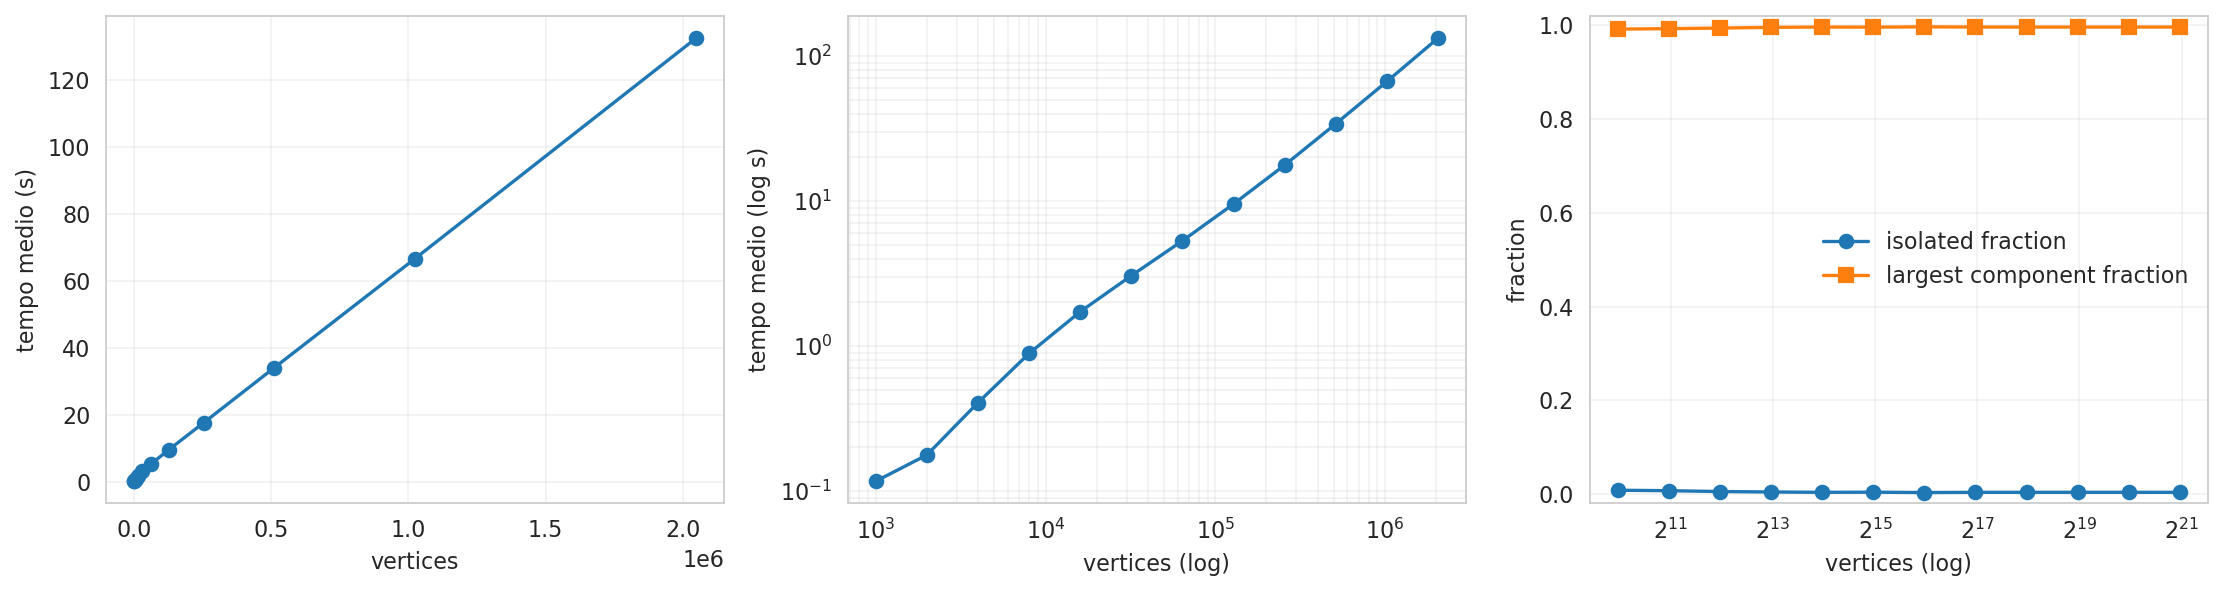

log-log slope vs n: 0.920
Results CSV: /home/gui-messias/Documents/Doutorado/SynCo/SCAtt_graph_generator/experiments/complexity/time_complexity_results.csv
Summary CSV: /home/gui-messias/Documents/Doutorado/SynCo/SCAtt_graph_generator/experiments/complexity/time_complexity_summary.csv
Figure: /home/gui-messias/Documents/Doutorado/SynCo/SCAtt_graph_generator/experiments/complexity/time_complexity_runtime.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), dpi=160)

axes[0].errorbar(
    summary["n_requested"],
    summary["time_mean_s"],
    yerr=summary["time_std_s"],
    marker="o",
    capsize=3,
)
axes[0].set_xlabel("vertices")
axes[0].set_ylabel("tempo medio (s)")
axes[0].grid(alpha=0.25)

axes[1].loglog(summary["n_requested"], summary["time_mean_s"], marker="o")
axes[1].set_xlabel("vertices (log)")
axes[1].set_ylabel("tempo medio (log s)")
axes[1].grid(alpha=0.25, which="both")

axes[2].plot(
    summary["n_requested"],
    summary["isolated_fraction_mean"],
    marker="o",
    label="isolated fraction",
)
if "largest_component_fraction_mean" in summary.columns:
    axes[2].plot(
        summary["n_requested"],
        summary["largest_component_fraction_mean"],
        marker="s",
        label="largest component fraction",
    )
axes[2].set_xscale("log", base=2)
axes[2].set_xlabel("vertices (log)")
axes[2].set_ylabel("fraction")
axes[2].set_ylim(-0.02, 1.02)
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False)

fig.tight_layout()
figure_path = OUTPUT_DIR / "time_complexity_runtime.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()

if len(summary) >= 2:
    slope, intercept = np.polyfit(np.log(summary["n_requested"]), np.log(summary["time_mean_s"]), deg=1)
    fit_path = OUTPUT_DIR / "time_complexity_fit.txt"
    fit_path.write_text(f"log(time) ~ {slope:.6f} * log(n) + {intercept:.6f}\n")
    print(f"log-log slope vs n: {slope:.3f}")

print(f"Results CSV: {results_path}")
print(f"Summary CSV: {summary_path}")
print(f"Figure: {figure_path}")